In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


# 🔎 Étape 3 : Analyse Exploratoire des Données (EDA) (Squelette Étudiant)

Cette étape correspond au troisième chapitre du cours. L'objectif est d'explorer et de résumer les propriétés statistiques fondamentales du dataset **Automobile** et de réaliser du **Feature Engineering** pour enrichir les modèles.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sys.path.append(os.path.abspath('..'))

print("Librairies importées pour l'EDA !")

Librairies importées pour l'EDA !


### 2. Chargement des données nettoyées

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

print(f"Shape : {df.shape}")
df.head()

Shape : (398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,2
1,15.0,8,350.0,165.0,3693,11.5,70,2
2,18.0,8,318.0,150.0,3436,11.0,70,2
3,16.0,8,304.0,150.0,3433,12.0,70,2
4,17.0,8,302.0,140.0,3449,10.5,70,2


### 3. Statistiques Descriptives

Résumés statistiques globaux et agrégations par groupe d'origine pour les variables clés du dataset.

In [4]:
print("=== Statistiques descriptives globales ===")
df.describe()

=== Statistiques descriptives globales ===


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.449749
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.775076
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,2.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,2.000000


In [5]:
print("=== Moyennes par origine (0=europe, 1=japan, 2=usa) ===")
df.groupby('origin')[['mpg', 'horsepower', 'weight', 'acceleration']].mean().round(2)

=== Moyennes par origine (0=europe, 1=japan, 2=usa) ===


,mpg,horsepower,weight,acceleration
origin,,,,
0,27.89,80.93,2423.30,16.79
1,30.45,79.84,2221.23,16.17
2,20.08,118.64,3361.93,15.03


### 4. Ingénierie de variables (Feature Engineering)

Création de deux nouvelles variables dérivées :
- **power_to_weight** : rapport puissance/poids, indicateur d'efficacité mécanique
- **mpg_category** : discrétisation de la consommation en 3 tertiles (faible / moyenne / élevée)

In [6]:
df_feat = df.copy()

# Rapport puissance / poids
df_feat['power_to_weight'] = df_feat['horsepower'] / df_feat['weight']

# Catégorisation de la consommation en 3 tertiles
df_feat['mpg_category'] = pd.qcut(
    df_feat['mpg'],
    q=3,
    labels=['faible', 'moyenne', 'élevée']
)

print(f"Shape après feature engineering : {df_feat.shape}")
print(f"Nouvelles colonnes : power_to_weight, mpg_category")
df_feat[['mpg', 'horsepower', 'weight', 'power_to_weight', 'mpg_category']].head()

Shape après feature engineering : (398, 10)
Nouvelles colonnes : power_to_weight, mpg_category


,mpg,horsepower,weight,power_to_weight,mpg_category
0,18.0,130.0,3504,0.037100,faible
1,15.0,165.0,3693,0.044679,faible
2,18.0,150.0,3436,0.043655,faible
3,16.0,150.0,3433,0.043694,faible
4,17.0,140.0,3449,0.040591,faible


### 5. Analyse des Corrélations

Matrice de corrélation de Pearson sur toutes les colonnes numériques (y compris `power_to_weight`), puis pairplot des variables clés coloré par origine.

In [7]:
# Sélection des colonnes numériques incluant power_to_weight
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year', 'origin', 'power_to_weight']

corr_matrix = df_feat[numeric_cols].corr(method='pearson')

print("=== Matrice de corrélation de Pearson ===")
print(corr_matrix.round(3))

=== Matrice de corrélation de Pearson ===
                   mpg  cylinders  displacement  horsepower  weight  \
mpg              1.000     -0.775        -0.804      -0.773  -0.832   
cylinders       -0.775      1.000         0.951       0.841   0.896   
displacement    -0.804      0.951         1.000       0.896   0.933   
horsepower      -0.773      0.841         0.896       1.000   0.862   
weight          -0.832      0.896         0.933       0.862   1.000   
acceleration     0.420     -0.505        -0.544      -0.687  -0.417   
model_year       0.579     -0.349        -0.370      -0.414  -0.307   
origin          -0.483      0.551         0.591       0.443   0.521   
power_to_weight -0.244      0.246         0.283       0.599   0.130   

                 acceleration  model_year  origin  power_to_weight  
mpg                     0.420       0.579  -0.483           -0.244  
cylinders              -0.505      -0.349   0.551            0.246  
displacement           -0.544      -0.37

Pairplot sauvegardé : ../data/processed/pairplot.png


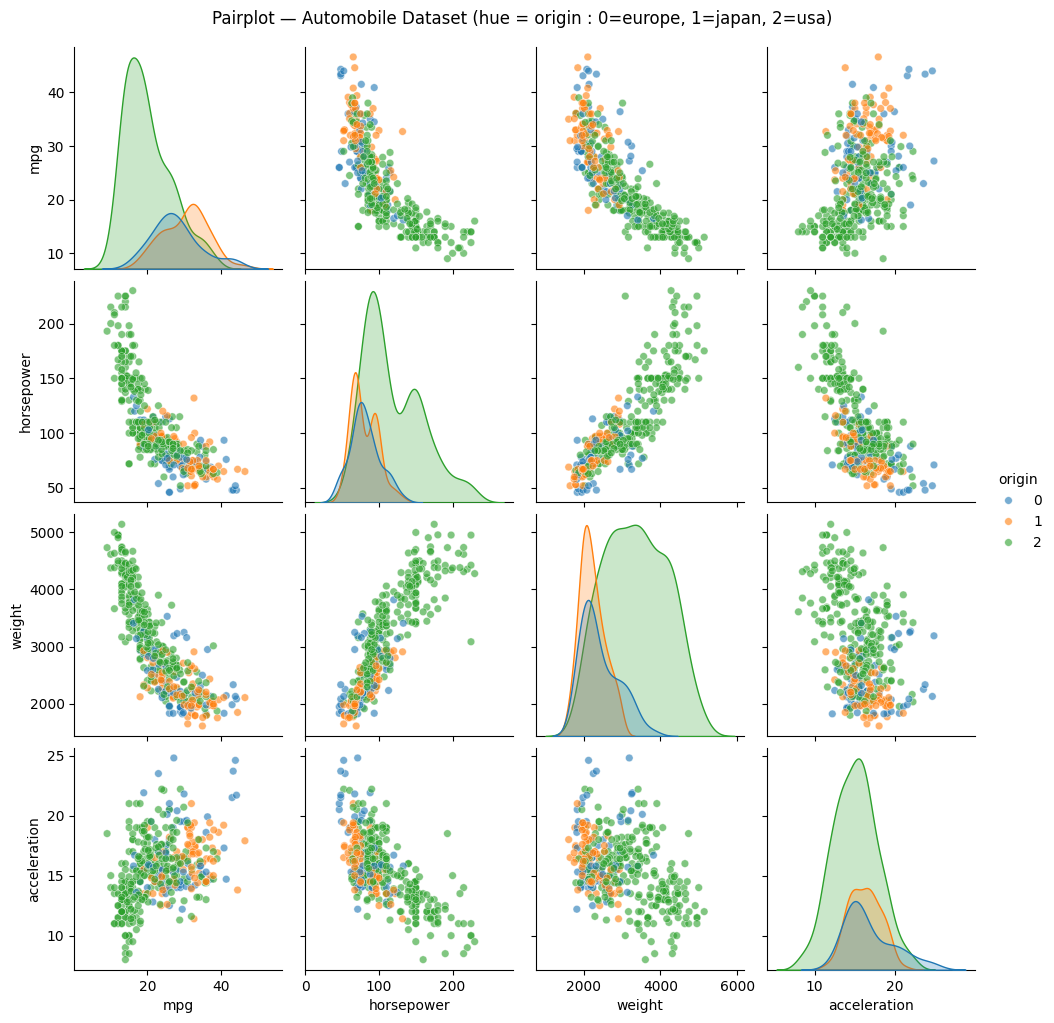

In [8]:
# Pairplot des variables clés coloré par origine
pairplot_cols = ['mpg', 'horsepower', 'weight', 'acceleration', 'origin']

pair_grid = sns.pairplot(
    df_feat[pairplot_cols],
    hue='origin',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
pair_grid.figure.suptitle(
    "Pairplot — Automobile Dataset (hue = origin : 0=europe, 1=japan, 2=usa)",
    y=1.02, fontsize=12
)

# Sauvegarde du pairplot
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
pairplot_path = os.path.join(output_dir, 'pairplot.png')
pair_grid.savefig(pairplot_path, dpi=120, bbox_inches='tight')

print(f"Pairplot sauvegardé : {pairplot_path}")
plt.show()